<a href="https://colab.research.google.com/github/Sk8133/codetech_internship/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary packages
!pip install torch torchvision matplotlib pillow


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import copy


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving image.jpg to image (1).jpg


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def image_loader(image_path, max_size=512):
    image = Image.open(image_path)
    size = max(image.size) if max(image.size) < max_size else max_size
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])])
    image = transform(image).unsqueeze(0)
    return image.to(device)

def imshow(tensor, title=None):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


In [ ]:
content_img = image_loader("image.jpg")     # your content image
style_img = image_loader("website.jpg")      # your style image


In [ ]:
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)
    def forward(self, img):
        return (img - self.mean) / self.std

def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(c, h * w)
    G = torch.mm(features, features.t())
    return G.div(c * h * w)

class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()
    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()
    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input


In [ ]:
cnn = models.vgg19(pretrained=True).features.to(device).eval()
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

def get_style_model_and_losses(cnn, norm_mean, norm_std, style_img, content_img,
                                content_layers=['conv_4'],
                                style_layers=['conv_1', 'conv_2', 'conv_3', 'conv_4']):
    cnn = copy.deepcopy(cnn)
    normalization = Normalization(norm_mean, norm_std).to(device)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'
        else:
            continue

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target = model(style_img).detach()
            style_loss = StyleLoss(target)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Trim the model after last loss
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break
    model = model[:i+1]

    return model, style_losses, content_losses


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:07<00:00, 74.0MB/s]


In [ ]:
def run_style_transfer(cnn, norm_mean, norm_std, content_img, style_img, input_img,
                       num_steps=300, style_weight=1e6, content_weight=1):
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, norm_mean, norm_std, style_img, content_img)

    input_img.requires_grad_(True)
    optimizer = optim.LBFGS([input_img])

    print("Starting Style Transfer...")
    run = [0]
    while run[0] <= num_steps:
        def closure():
            input_img.data.clamp_(0, 1)
            optimizer.zero_grad()
            model(input_img)
            style_score = sum(sl.loss for sl in style_losses)
            content_score = sum(cl.loss for cl in content_losses)
            loss = style_weight * style_score + content_weight * content_score
            loss.backward()
            run[0] += 1
            if run[0] % 50 == 0:
                print(f"Step {run[0]}: Style Loss = {style_score:.4f}, Content Loss = {content_score:.4f}")
            return loss
        optimizer.step(closure)
    input_img.data.clamp_(0, 1)
    return input_img


Starting Style Transfer...
Step 50: Style Loss = 2.1712, Content Loss = 577.5829
Step 100: Style Loss = 2.1712, Content Loss = 577.5829
Step 150: Style Loss = 2.1712, Content Loss = 577.5829
Step 200: Style Loss = 2.1712, Content Loss = 577.5829
Step 250: Style Loss = 2.1712, Content Loss = 577.5829
Step 300: Style Loss = 2.1712, Content Loss = 577.5829


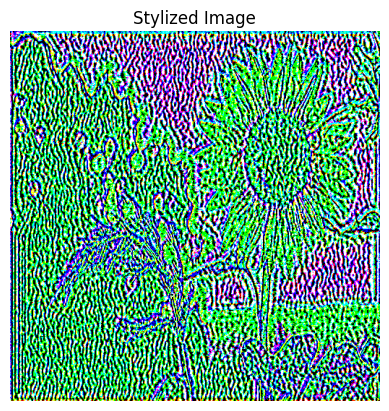

In [ ]:
input_img = content_img.clone()
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img)

imshow(output, title='Stylized Image')


In [ ]:
from torchvision.utils import save_image
save_image(output, 'stylized_output.jpg')

# Download the image
files.download('stylized_output.jpg')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>